# Resume Matcher — Evaluation

This notebook walks through how the matcher performed on the synthetic test set I created. The JD used is for a Senior AI Applications Engineer role at Ema. I manually labeled 10 resumes and compared the model's ranking against those labels.

In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from src.matcher import rank_resumes
from src.evaluator import evaluate, get_label
from src.utils import load_text, load_resumes

In [2]:
jd_text = load_text('../data/job_description.txt')
resumes = load_resumes('../data/resumes')
print(f'loaded {len(resumes)} resumes')

loaded 10 resumes


## Scores

In [3]:
ranked = rank_resumes(jd_text, resumes)

LABEL_MAP = {1.0: 'Good Match', 0.5: 'Partial Match', 0.0: 'Poor Match'}

rows = []
for i, r in enumerate(ranked, 1):
    name = r['name'].replace('.txt', '')
    score = r['score']
    manual_lbl = get_label(r['name'])
    predicted = 'Good Match' if score >= 0.75 else ('Partial Match' if score >= 0.55 else 'Poor Match')
    rows.append({
        'Rank': i,
        'Resume': name,
        'Score': score,
        'Predicted': predicted,
        'Manual Label': LABEL_MAP.get(manual_lbl, 'Unknown'),
        'Manual Score': manual_lbl
    })

df = pd.DataFrame(rows)
df

,Rank,Resume,Score,Predicted,Manual Label,Manual Score
0,1,resume_01_arjun_sharma,0.6994,Partial Match,Good Match,1.0
1,2,resume_02_priya_nair,0.6581,Partial Match,Good Match,1.0
2,3,resume_03_rahul_verma,0.6264,Partial Match,Good Match,1.0
3,4,resume_10_sathvik_kantharaj,0.6147,Partial Match,Good Match,1.0
4,5,resume_06_aditya_joshi,0.5876,Partial Match,Partial Match,0.5
5,6,resume_04_sneha_kulkarni,0.5239,Poor Match,Partial Match,0.5
6,7,resume_08_vijay_kumar,0.4410,Poor Match,Poor Match,0.0
7,8,resume_05_kiran_reddy,0.4234,Poor Match,Partial Match,0.5
8,9,resume_07_meera_thomas,0.3219,Poor Match,Poor Match,0.0
9,10,resume_09_pooja_mehta,0.2899,Poor Match,Poor Match,0.0


ranked = rank_resumes(jd_text, resumes)

LABEL_MAP = {1.0: 'Good Match', 0.5: 'Partial Match', 0.0: 'Poor Match'}

rows = []
for i, r in enumerate(ranked, 1):
    name = r['name'].replace('.txt', '')
    score = r['score']
    manual_lbl = get_label(r['name'])
    predicted = 'Good Match' if score >= 0.60 else ('Partial Match' if score >= 0.50 else 'Poor Match')
    rows.append({
        'Rank': i,
        'Resume': name,
        'Score': score,
        'Predicted': predicted,
        'Manual Label': LABEL_MAP.get(manual_lbl, 'Unknown'),
        'Manual Score': manual_lbl
    })

df = pd.DataFrame(rows)
df

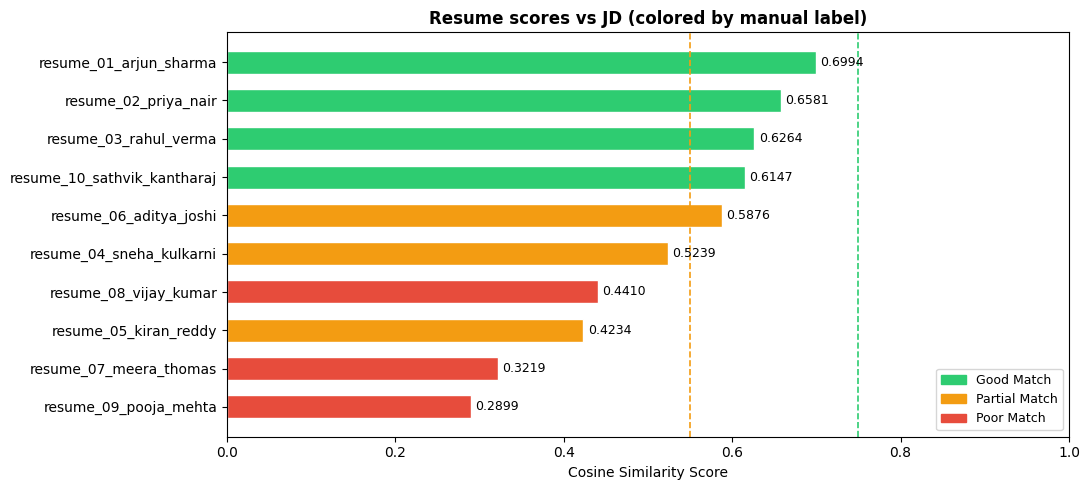

In [4]:
COLOR_MAP = {'Good Match': '#2ecc71', 'Partial Match': '#f39c12', 'Poor Match': '#e74c3c'}
colors = [COLOR_MAP[lbl] for lbl in df['Manual Label']]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(df['Resume'], df['Score'], color=colors, edgecolor='white', height=0.6)

ax.axvline(0.75, color='#2ecc71', linestyle='--', linewidth=1.2, label='Good threshold (0.75)')
ax.axvline(0.55, color='#f39c12', linestyle='--', linewidth=1.2, label='Partial threshold (0.55)')

for bar, score in zip(bars, df['Score']):
    ax.text(score + 0.005, bar.get_y() + bar.get_height()/2,
            f'{score:.4f}', va='center', fontsize=9)

patches = [mpatches.Patch(color=c, label=l) for l, c in COLOR_MAP.items()]
ax.legend(handles=patches + ax.get_legend_handles_labels()[0][2:], loc='lower right', fontsize=9)

ax.set_xlabel('Cosine Similarity Score')
ax.set_title('Resume scores vs JD (colored by manual label)', fontweight='bold')
ax.set_xlim(0, 1.0)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../score_distribution.png', dpi=150)
plt.show()

## Predicted vs manual labels

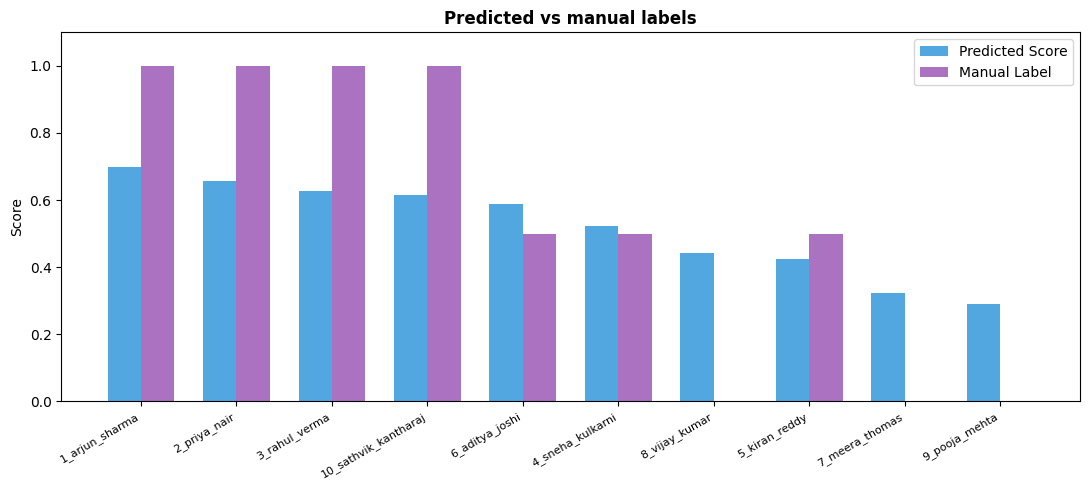

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(df))
width = 0.35

ax.bar([i - width/2 for i in x], df['Score'],        width, label='Predicted Score', color='#3498db', alpha=0.85)
ax.bar([i + width/2 for i in x], df['Manual Score'], width, label='Manual Label',    color='#9b59b6', alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels(df['Resume'].str.replace('resume_0', '').str.replace('resume_', ''), rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Score')
ax.set_title('Predicted vs manual labels', fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig('../predicted_vs_manual.png', dpi=150)
plt.show()

## Metrics

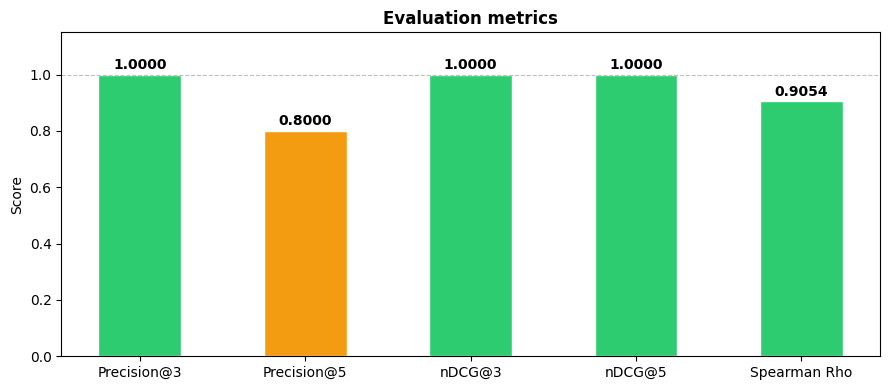

,Metric,Score
0,Precision@3,1.0000
1,Precision@5,0.8000
2,nDCG@3,1.0000
3,nDCG@5,1.0000
4,Spearman Rho,0.9054


In [6]:
metrics = evaluate(ranked)

metrics_df = pd.DataFrame([
    {'Metric': 'Precision@3',  'Score': metrics['precision_at_3']},
    {'Metric': 'Precision@5',  'Score': metrics['precision_at_5']},
    {'Metric': 'nDCG@3',       'Score': metrics['ndcg_at_3']},
    {'Metric': 'nDCG@5',       'Score': metrics['ndcg_at_5']},
    {'Metric': 'Spearman Rho', 'Score': metrics['spearman_rho']},
])

fig, ax = plt.subplots(figsize=(9, 4))
bar_colors = ['#2ecc71' if s >= 0.9 else '#f39c12' if s >= 0.7 else '#e74c3c' for s in metrics_df['Score']]
bars = ax.bar(metrics_df['Metric'], metrics_df['Score'], color=bar_colors, edgecolor='white', width=0.5)

for bar, score in zip(bars, metrics_df['Score']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{score:.4f}', ha='center', fontsize=10, fontweight='bold')

ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Evaluation metrics', fontweight='bold')
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.savefig('../evaluation_metrics.png', dpi=150)
plt.show()

metrics_df

## What the results show

The top 3 results were all genuine good matches — Precision@3 and nDCG@3 both hit 1.0, which is the best possible. Spearman Rho at 0.905 means the overall ranking is closely aligned with how I manually labeled them.

The one miss worth noting: Vijay Kumar (pure DevOps background, no AI experience) scored 0.60 and got predicted as Partial Match instead of Poor. That happened because his resume has cloud and monitoring experience that overlaps with some JD language — the model picked up on that. It's a legitimate edge case and something that a hard filter on required skills would catch.

**If this were running on real labeled data at scale**, the metrics I'd prioritize are:
- **nDCG@K** — most important for ranking tasks because it penalizes putting a weaker candidate above a stronger one, not just binary correct/incorrect
- **Precision@K** — directly tied to recruiter workflow, since they only review the top N results
- **Recall@K** — equally important to make sure strong candidates aren't getting buried
- **Spearman Rho** — useful as a single summary number to track across model versions